# Exploratory Data Analysis

## Load Data

In [4]:
# %pip install pandas numpy matplotlib seaborn statsmodels arch scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
from pathlib import Path
project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.utils import load_and_preprocess_data
# load data
file_path = '../Case_Study_Data_JNM.csv'
data, returns = load_and_preprocess_data(file_path)
returns.head()

,1,2,3,4,5
date,,,,,
2001-01-31,0.019259,0.007933,-0.025895,0.029028,0.013580
2001-02-28,-0.084626,0.011747,0.007353,-0.124214,-0.037645
2001-03-31,-0.065848,0.003618,-0.034438,-0.097128,-0.031738
2001-04-30,0.073714,-0.011915,0.021438,0.112584,0.030010
2001-05-31,-0.013033,0.003687,0.011842,-0.019486,-0.004708


<!-- ## 2. Plot Time Series -$\to$

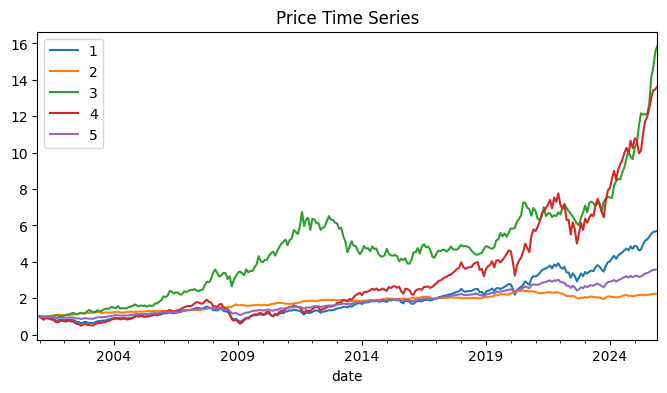

In [6]:
# plot time series of prices
data.plot(figsize=(8, 4), title='Price Time Series')
plt.show()

**Observations (Price Data):**
- **Different Trends:** Asset 3 and 4 exponential growth $\to$ could be equities or gold. 2 is stable $\to$ could be fixed income instrument
- **Crisis Correlation:** simultaneous drawdowns during 2008 (Global Financial Crisis) and 2020 (COVID-19) $\to$ tail dependence.
- periods of low vs. high trend (e.g., after 2023 acceleration for Asset 3)

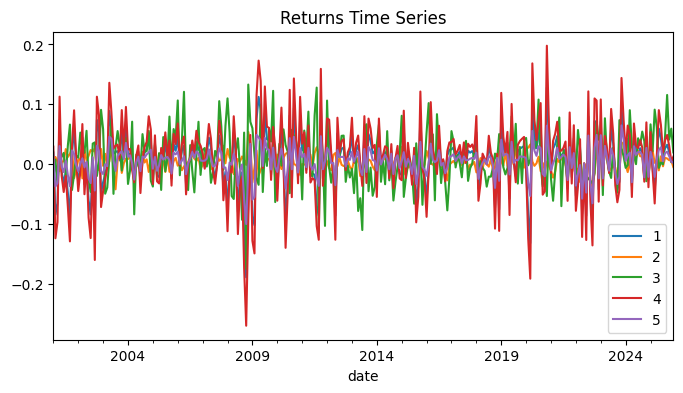

In [7]:
# plot time series of returns
returns.plot(figsize=(8, 4), title='Returns Time Series')
plt.show()

**Observations (Return Data):**
- **Heteroskedasticity:**  volatility clustering is visible (e.g., 2008, 2020) $\to$ large changes follow large changes
- Asset 4: widest return spread (highest risk), Asset 2 is nearly flat (low risk)
- **Mean Reversion:** stable mean (near zero) $\to$ stationarity

## Histograms and QQ-Plots

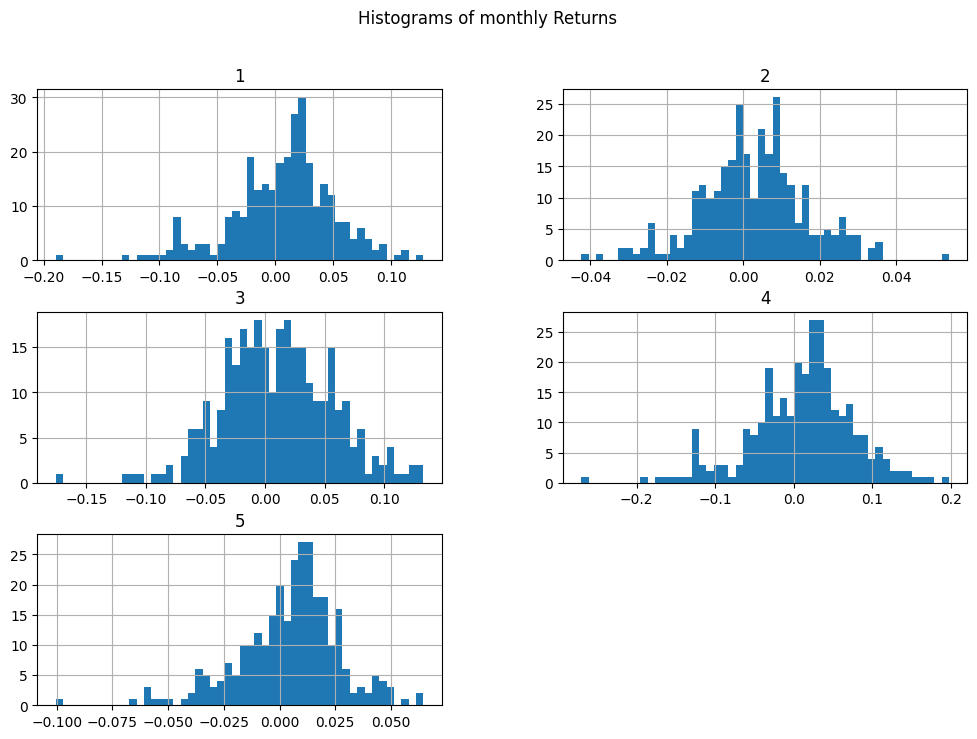

In [8]:
# plot histograms
returns.hist(bins=50, figsize=(12, 8))
plt.suptitle('Histograms of monthly Returns')
plt.show()

**Observations (Distribution):**
- **Roughly normally distributed**
- **Fat Tails:** Extreme values (e.g., Asset 4 < -0.10) occur frequently $\to$ fat tails
- **Peak at Mean:** concentration of returns around mean (peakedness)
- **Skewness:** negative skew visible in equity-like (3+4, maybe also in 1) (longer left tails) $\to$ crashes are more violent than rallies

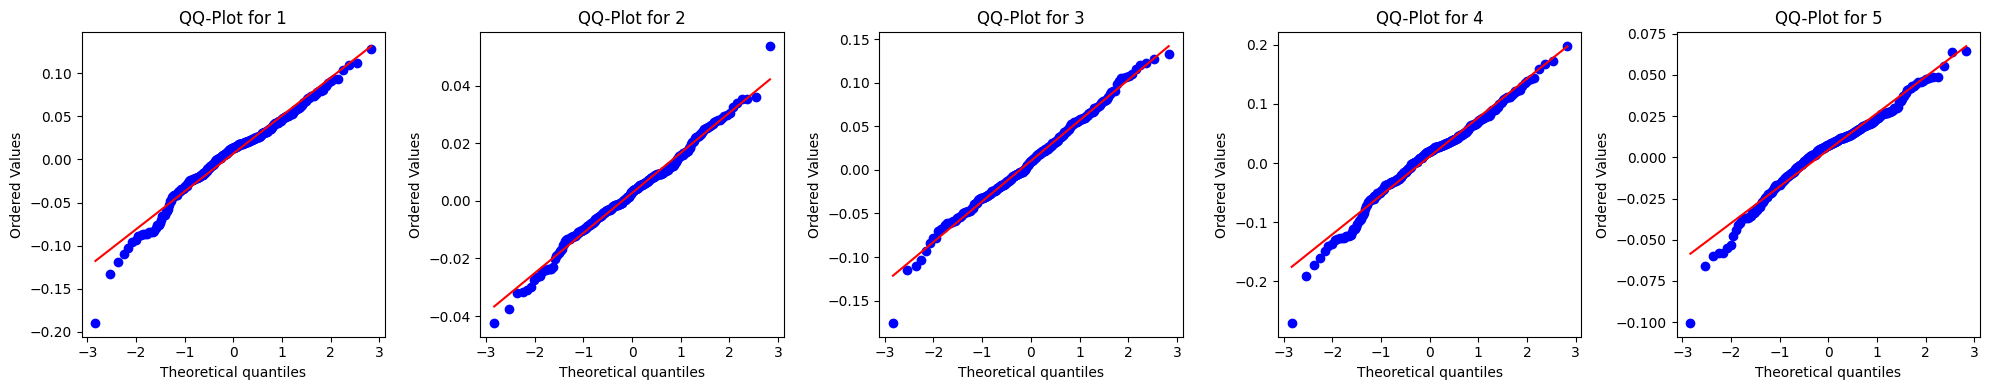

In [9]:
# plot qq-plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(returns.columns):
    stats.probplot(returns[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot for {col}')
plt.tight_layout()
plt.show()

**Observations:**
- **Fat Tails:** blue Dots diverge from red line at the ends
- **Conclusion:** Extreme events are more frequent than Normal distribution predicts.

## 4. Summary Statistics

In [10]:
summary_stats = returns.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
1,300.0,0.006821,0.044370,-0.189602,-0.018438,0.013004,0.032098,0.127861
2,300.0,0.002785,0.013916,-0.042374,-0.005402,0.003137,0.010424,0.053775
3,300.0,0.010327,0.046413,-0.175604,-0.020672,0.010288,0.040633,0.132835
4,300.0,0.010986,0.066306,-0.270462,-0.027528,0.019569,0.048531,0.197797
5,300.0,0.004509,0.022492,-0.100435,-0.006921,0.007424,0.017627,0.064515


In [11]:
distribution_stats = summary_stats.copy()
distribution_stats['skew'] = returns.skew()
distribution_stats['kurt'] = returns.kurt()
distribution_stats['sem'] = returns.sem()
distribution_stats['var'] = returns.var()
distribution_stats = distribution_stats[['count','mean','std','var','min','max','skew','kurt']]
distribution_stats

,count,mean,std,var,min,max,skew,kurt
1,300.0,0.006821,0.044370,0.001969,-0.189602,0.127861,-0.634043,1.415463
2,300.0,0.002785,0.013916,0.000194,-0.042374,0.053775,-0.022974,0.735767
3,300.0,0.010327,0.046413,0.002154,-0.175604,0.132835,-0.066126,0.523666
4,300.0,0.010986,0.066306,0.004396,-0.270462,0.197797,-0.534254,1.202299
5,300.0,0.004509,0.022492,0.000506,-0.100435,0.064515,-0.693021,1.849615


**Observations (Summary Stats):**
- **Risk-Return Trade-off:** Asset 4 has highest mean (0.011) and highest volatility (0.066) $\to$ High Risk/High Reward, Asset 2 is the most stable.
- **Negative Skewness:** All assets have negative skew (especially Asset 5 at -0.69) $\to$ Downside crashes are more extreme than upside rallies
- **Excess Kurtosis:** Positive kurtosis across the board (Assets 1 & 5 are highest) $\to$ fat tails
- **Modeling Implication:** Gaussian (Normal) assumption is insufficient $\to$ models must account for skewness and heavy tails (e.g., Student-t distribution)

## 5. Autocorrelation Analysis

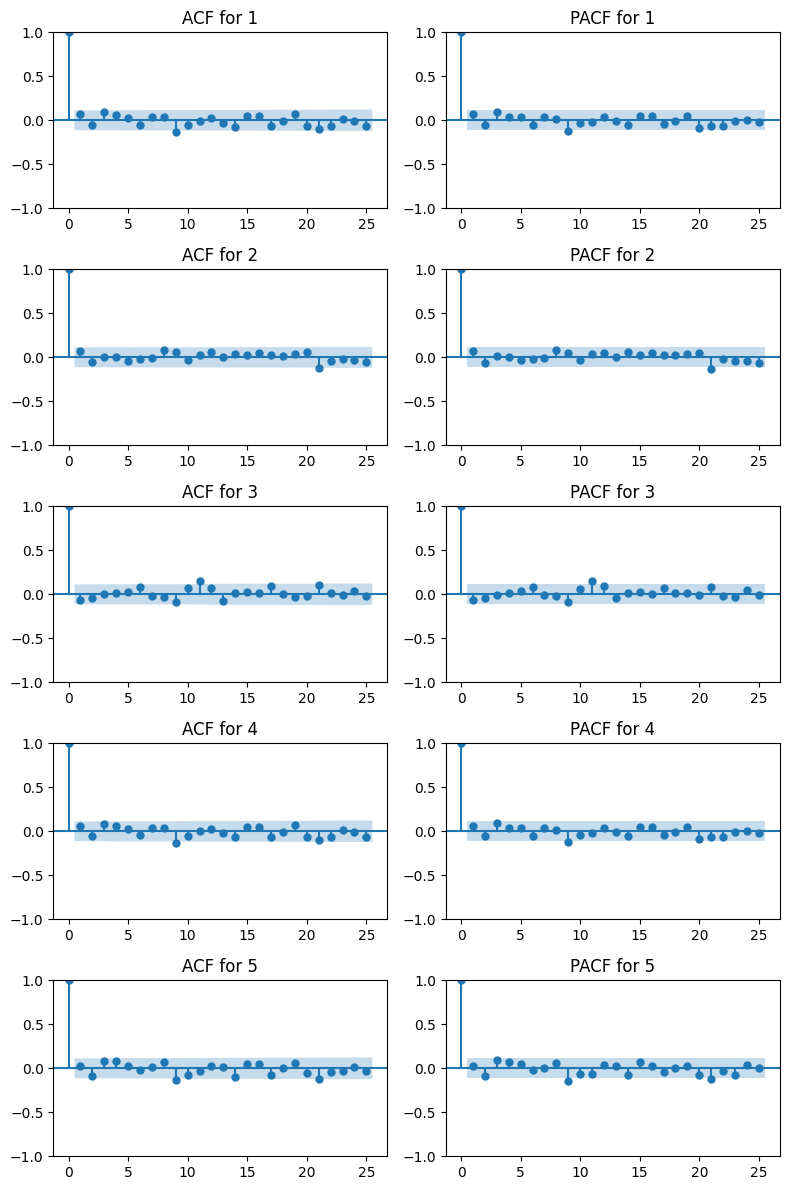

In [12]:
# plot acf and pacf for returns
fig, axes = plt.subplots(5, 2, figsize=(8, 12))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col], ax=axes[i, 0], title=f'ACF for {col}')
    plot_pacf(returns[col], ax=axes[i, 1], title=f'PACF for {col}')
plt.tight_layout()
plt.show()

**Observations:**
- **No Serial Correlation:** ACF & PACF coefficients mostly stay within the ci
- **Random Walk:** Past returns dont significantly predict future returns

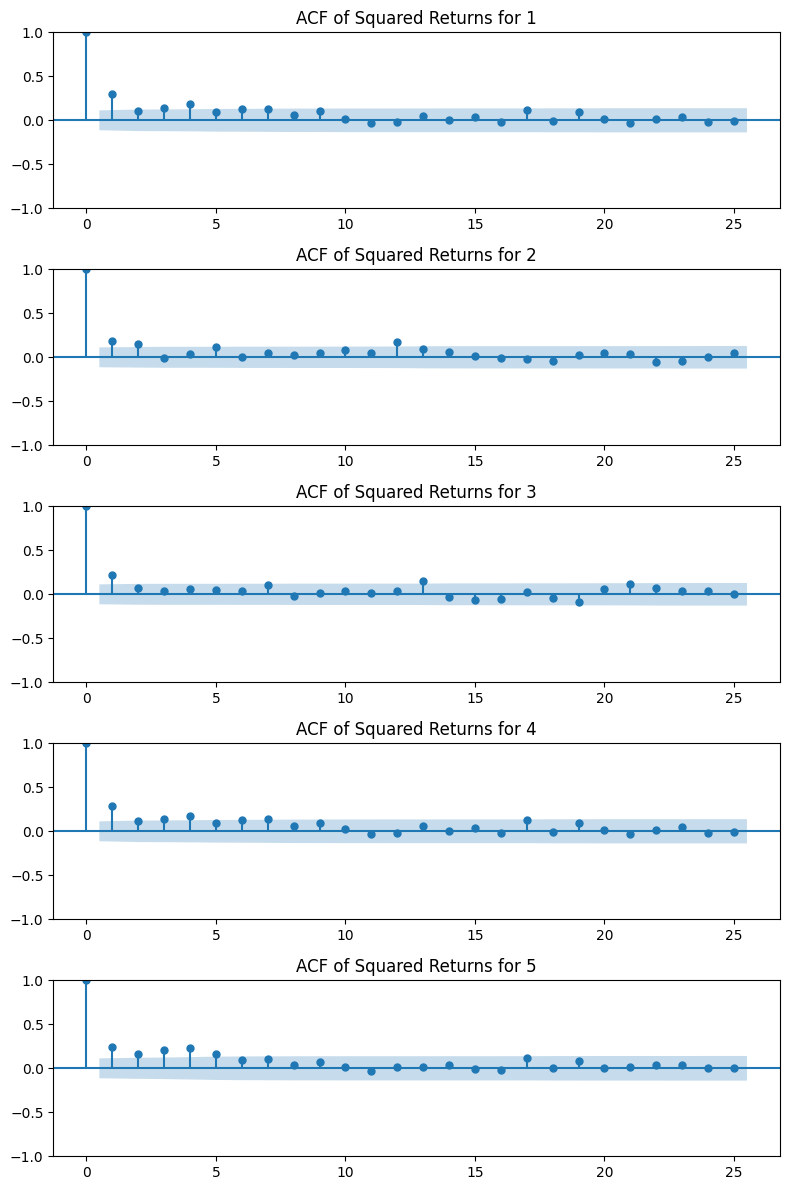

In [13]:
# plot acf for squared returns (volatility clustering)
fig, axes = plt.subplots(5, 1, figsize=(8, 12))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col]**2, ax=axes[i], title=f'ACF of Squared Returns for {col}')
plt.tight_layout()
plt.show()

**Observations (Squared Returns):**
- **Volatility Clustering:** Significant positive spikes at Lag 1 and beyond (especially Assets 1, 4, and 5).
- **Persistence:** correlation decays slowly $\to$ high volatility periods persist over time $\to$ **GARCH(1,1)** model

## Correlation Matrix

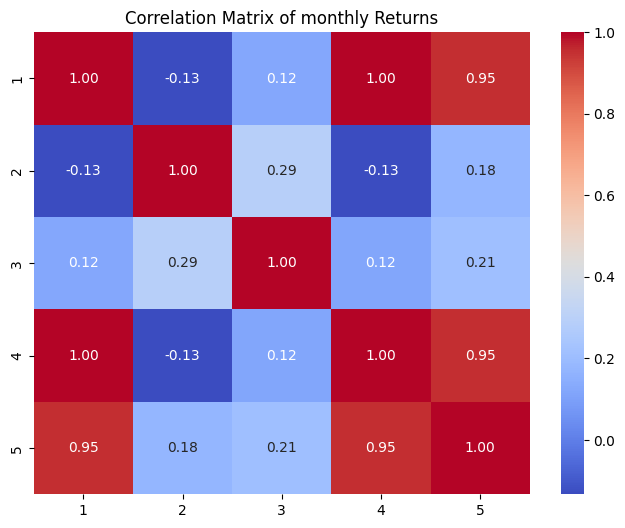

,1,2,3,4,5
1,1.000000,-0.133055,0.119434,0.999812,0.952145
2,-0.133055,1.000000,0.291278,-0.132708,0.175432
3,0.119434,0.291278,1.000000,0.118462,0.208866
4,0.999812,-0.132708,0.118462,1.000000,0.951665
5,0.952145,0.175432,0.208866,0.951665,1.000000


In [14]:
# calculate correlation matrix
correlation_matrix = returns.corr()

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of monthly Returns')
plt.show()

correlation_matrix

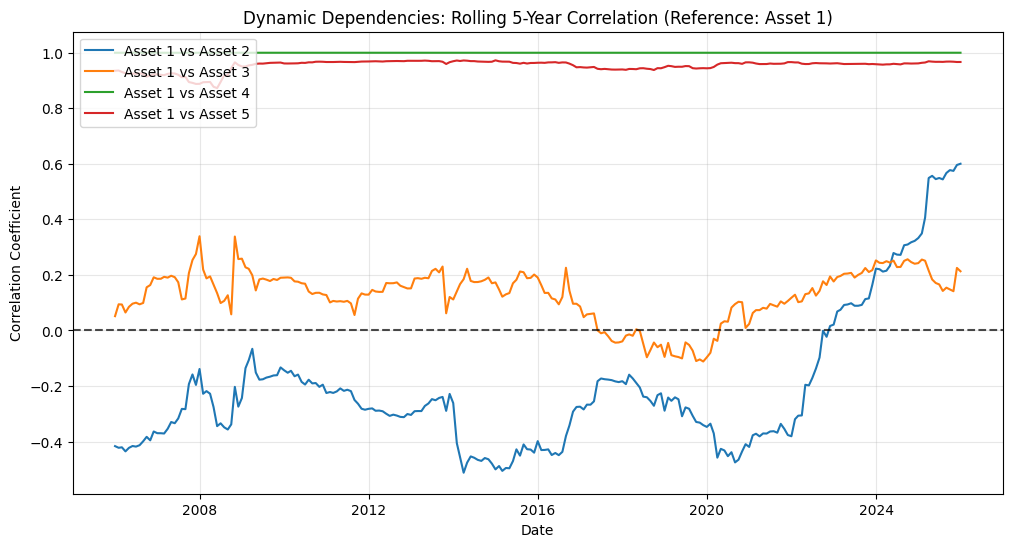

In [15]:
# rolling correlation of Asset 1 vs All Others
plt.figure(figsize=(12, 6))
for col in returns.columns:
    if col != '1':
        # rolling correlation (5year window)
        roll_corr = returns['1'].rolling(window=60).corr(returns[col])
        plt.plot(roll_corr, label=f'Asset 1 vs Asset {col}', linewidth=1.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Dynamic Dependencies: Rolling 5-Year Correlation (Reference: Asset 1)')
plt.legend(loc='upper left')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

**Observations:**
- **Perfect Correlation:** Assets **1, 4** have almost perfect correlation $\to$ likely same underlying asset  (equities), perhaps 4 is some leveraged version of 1 (e.g. ETF)
- **High Correlation:** **1, 4** have very high correlation with **5** $\to$ likely same asset  class (also equities)
- **Asset 2:** Low to Negative correlation (-0.13) with equities $\to$ acts as hedge (perhaps Bonds) $\to$ regime dependence: neg correlation in low inflation era, positive correlation since inflation crisis in 2022.
- **Asset 3:** Low positive correlation with equity cluster $\to$ true diversifier and massive rally after 2022 $\to$ likely gold
- **Modeling Implication:** dependency between 1, 4, and 5 must be preserved $\to$ **Student-t Copula** is ideal here to capture both linear correlation and the joint tail risks (crashes happening together lke GFC)

For presentation: 
**Observations:**
- **Equity Cluster (Assets 1, 4, 5):**
    - **Asset 1 & 4 (Perfect Correlation):** Correlation $\approx 1.0$ implies Asset 4 is likely a **Leveraged ETF** (e.g., 2x S&P 500) of Asset 1. They share the exact same risk driver.
    - **Asset 5 (High Correlation):** Correlation $> 0.95$ with Asset 1 suggests a similar asset class but different region (e.g., **European Equities** vs US).
- **The Hedge (Asset 2):**
    - **Regime Dependence:** Acts as a diversifier in low-inflation regimes (negative correlation), but correlation flips positive during inflation shocks (2022). This behavior is characteristic of **Government Bonds**.
- **The Diversifier (Asset 3):**
    - **Decoupled Returns:** Low positive correlation ($0.12$) and moderate volatility suggests it is neither Equity nor Bond.
    - **Inflation/Safe Haven:** The massive rally post-2022 (inflationary period) combined with low beta points to **Gold/Precious Metals**.
- **Modeling Implication:**
    - **Marginals:** Must use **GARCH** to capture the volatility clustering clearly visible in all assets.
    - **Dependency:** A **Student-t Copula** is mandatory. A Gaussian copula would fail to capture the "Joint Tail Risk" (simultaneous crashes of 1, 4, and 5) and would misprice the portfolio during crisis events.

## Tail Dependence

<Figure size 1200x600 with 0 Axes>

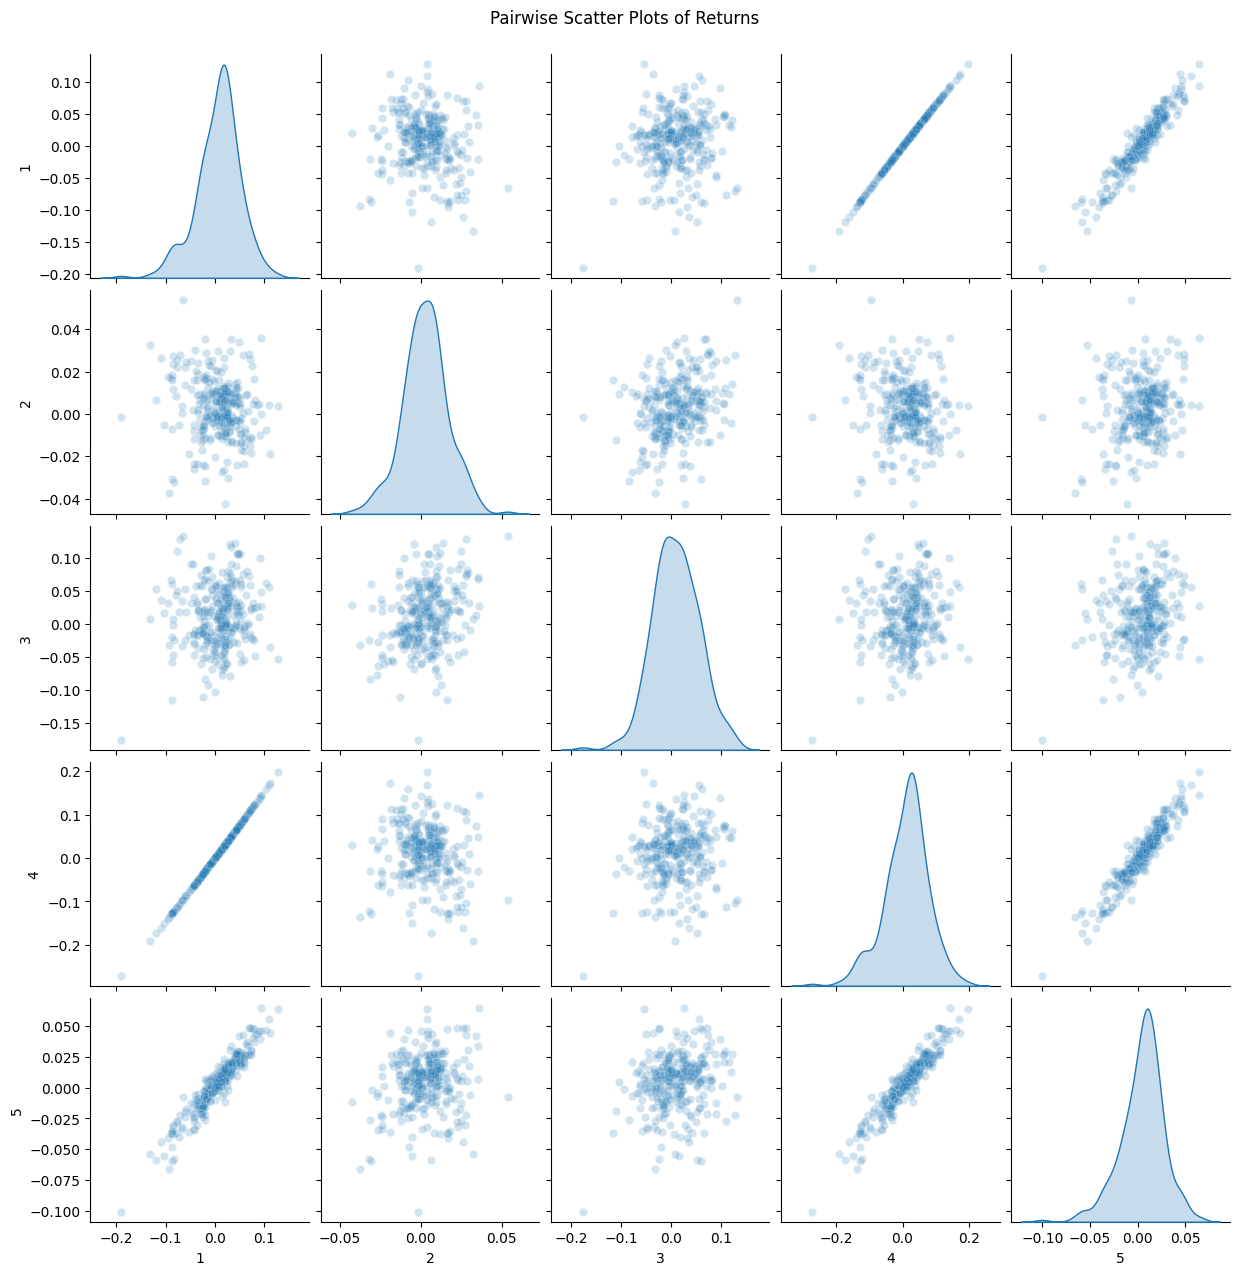

In [18]:
plt.figure(figsize=(8, 8))
sns.pairplot(returns, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairwise Scatter Plots of Returns', y=1.02)
plt.show()

**Observations (Tail Dependence):**
- **Symmetric Dependence:** scatter plots show similar patterns of correlation for both extreme downside and upside events
- **Equity Behavior:** Assets 1, 4, and 5 move together strongly in both tails -> when one crashes, the others crash
- **Bond Behavior:** Asset 2 shows very little correlation with the equity cluster during tail events -> diversifier, but could be dependent on inflationary regime
- **Gold Behavior:** Asset 3 also shows low correlation with equities in tail events -> diversifier